# 02b Exploratory Data Analysis

This notebook inspects the cleaned iron ore dataset before feature engineering.

Focus areas:
- long-term market dynamics
- seasonality and calendar effects
- turbulence and volatility clustering
- core feature relationships

Figures are also saved to `presentation/figures` for slide reuse.


## Research Paper Alignment

This notebook connects the cleaned market data to the main paper themes: market turbulence, conditional variance, and the need to move beyond static linear forecasting assumptions.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "params.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 130

ASSET_DIR = PROJECT_ROOT / "presentation" / "figures"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

params = yaml.safe_load(Path("params.yaml").read_text(encoding="utf-8"))


In [2]:
params["data_cleaning"]


{'input_path': 'dvc_pipeline/data/raw/iron_ore_raw.csv',
 'output_path': 'dvc_pipeline/data/processed/iron_ore_clean.csv',
 'report_path': 'dvc_pipeline/reports/cleaning_report.json',
 'keep_weekdays_only': True}

In [3]:
clean_path = Path(params["data_cleaning"]["output_path"])
if not clean_path.exists():
    subprocess.run([sys.executable, "dvc_pipeline/src/data_cleaning.py"], check=True)

clean_df = pd.read_csv(clean_path)
clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="coerce")
clean_df = clean_df.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)

clean_df["Return_1d"] = clean_df["Price"].pct_change()
clean_df["Volatility_14d"] = clean_df["Return_1d"].rolling(14).std()
clean_df["Month"] = pd.Categorical(
    clean_df["Date"].dt.strftime("%b"),
    categories=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    ordered=True,
)
clean_df["Weekday"] = pd.Categorical(
    clean_df["Date"].dt.strftime("%a"),
    categories=["Mon", "Tue", "Wed", "Thu", "Fri"],
    ordered=True,
)

clean_df.head(), clean_df.shape


(        Date  Price   Open   High    Low   Vol.  Change %  Return_1d  \
 0 2016-01-04  41.95  41.95  41.95  41.95  120.0      5.99        NaN   
 1 2016-01-05  41.69  41.69  41.69  41.69  400.0     -0.62  -0.006198   
 2 2016-01-06  41.12  41.12  41.12  41.12  210.0     -1.37  -0.013672   
 3 2016-01-07  41.14  41.14  41.14  41.14   10.0      0.05   0.000486   
 4 2016-01-08  41.06  41.06  41.06  41.06   90.0     -0.19  -0.001945   
 
    Volatility_14d Month Weekday  
 0             NaN   Jan     Mon  
 1             NaN   Jan     Tue  
 2             NaN   Jan     Wed  
 3             NaN   Jan     Thu  
 4             NaN   Jan     Fri  ,
 (2264, 11))

In [4]:
summary = pd.DataFrame(
    {
        "rows": [len(clean_df)],
        "start_date": [clean_df["Date"].min().strftime("%Y-%m-%d")],
        "end_date": [clean_df["Date"].max().strftime("%Y-%m-%d")],
        "price_mean": [clean_df["Price"].mean()],
        "price_std": [clean_df["Price"].std()],
        "volume_mean": [clean_df["Vol."].mean()],
        "max_14d_volatility": [clean_df["Volatility_14d"].max()],
    }
)
summary, clean_df[["Price", "Open", "High", "Low", "Vol.", "Change %"]].describe().T


(   rows  start_date    end_date  price_mean  price_std  volume_mean  \
 0  2264  2016-01-04  2024-12-31  100.914086  35.429444    12.756184   
 
    max_14d_volatility  
 0            0.046743  ,
            count        mean        std    min      25%    50%       75%  \
 Price     2264.0  100.914086  35.429444  40.33  72.7450  96.36  120.4700   
 Open      2264.0  100.905954  35.433437  40.33  72.7075  96.36  120.4700   
 High      2264.0  100.909284  35.430877  40.33  72.7450  96.36  120.4700   
 Low       2264.0  100.901356  35.436868  40.33  72.6450  96.36  120.4700   
 Vol.      2264.0   12.756184  52.108021   0.00   0.0000   0.00    0.0000   
 Change %  2264.0    0.059108   1.807013 -15.38  -0.3400   0.04    0.4525   
 
              max  
 Price     219.77  
 Open      219.77  
 High      219.77  
 Low       219.77  
 Vol.      920.00  
 Change %   16.05  )

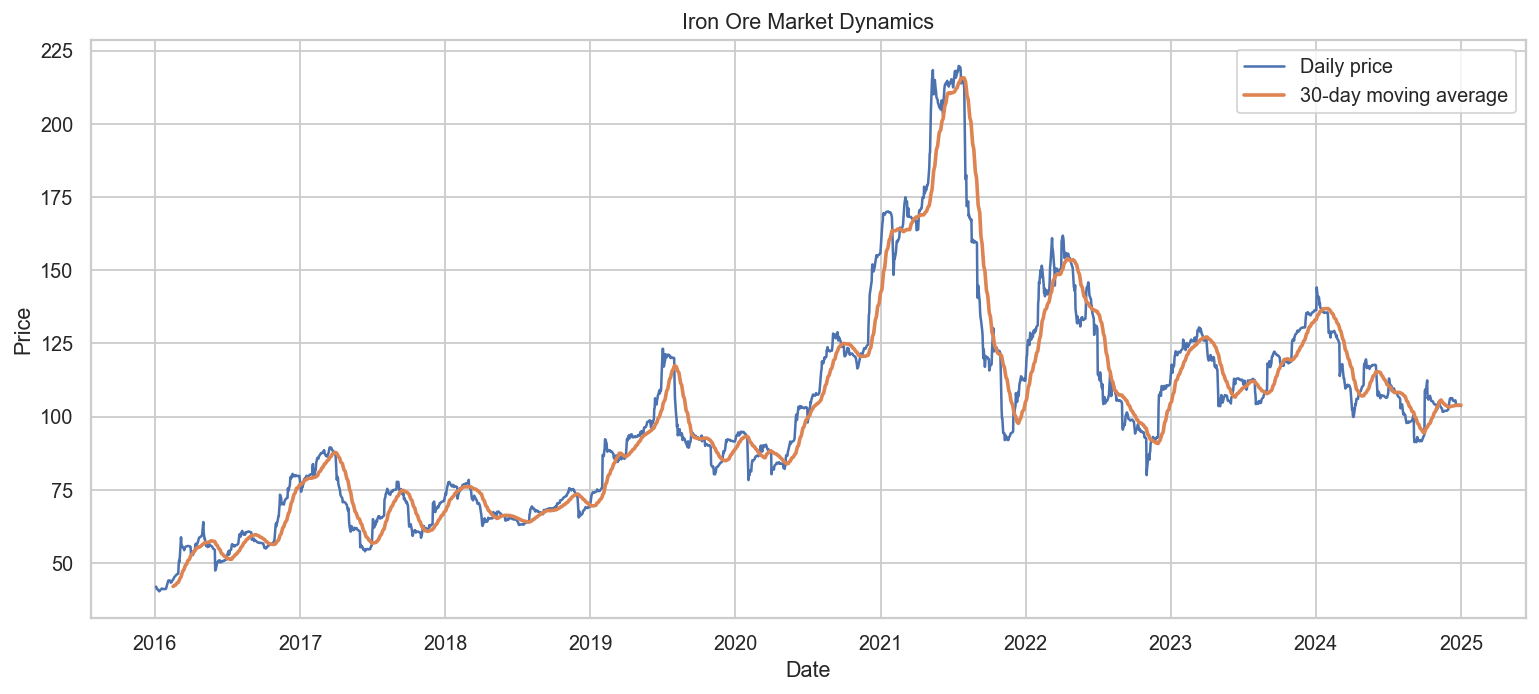

In [5]:
trend_df = clean_df[["Date", "Price"]].copy()
trend_df["Price_30dma"] = trend_df["Price"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.lineplot(data=trend_df, x="Date", y="Price", ax=ax, label="Daily price", linewidth=1.4)
sns.lineplot(data=trend_df, x="Date", y="Price_30dma", ax=ax, label="30-day moving average", linewidth=2.0)
ax.set_title("Iron Ore Market Dynamics")
ax.set_ylabel("Price")
fig.tight_layout()
fig.savefig(ASSET_DIR / "01_market_dynamics.png", bbox_inches="tight")
plt.show()


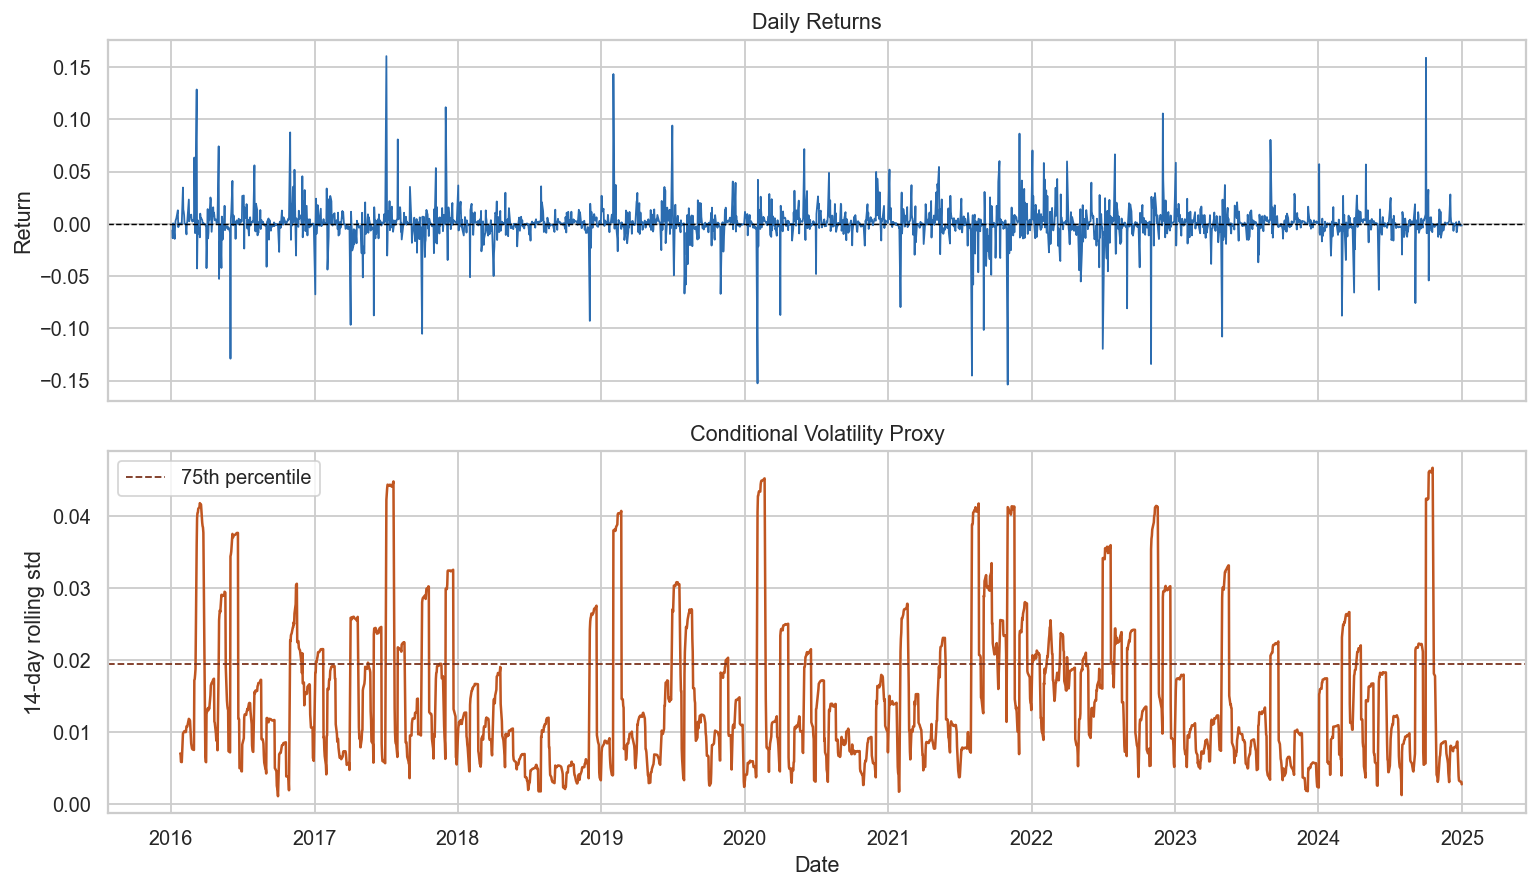

In [6]:
vol_threshold = clean_df["Volatility_14d"].dropna().quantile(0.75)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
sns.lineplot(data=clean_df, x="Date", y="Return_1d", ax=axes[0], color="#2b6cb0", linewidth=1.0)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Daily Returns")
axes[0].set_ylabel("Return")

sns.lineplot(data=clean_df, x="Date", y="Volatility_14d", ax=axes[1], color="#c05621", linewidth=1.4)
axes[1].axhline(vol_threshold, color="#7b341e", linestyle="--", linewidth=1.0, label="75th percentile")
axes[1].set_title("Conditional Volatility Proxy")
axes[1].set_ylabel("14-day rolling std")
axes[1].legend()
fig.tight_layout()
fig.savefig(ASSET_DIR / "02_volatility_regime.png", bbox_inches="tight")
plt.show()


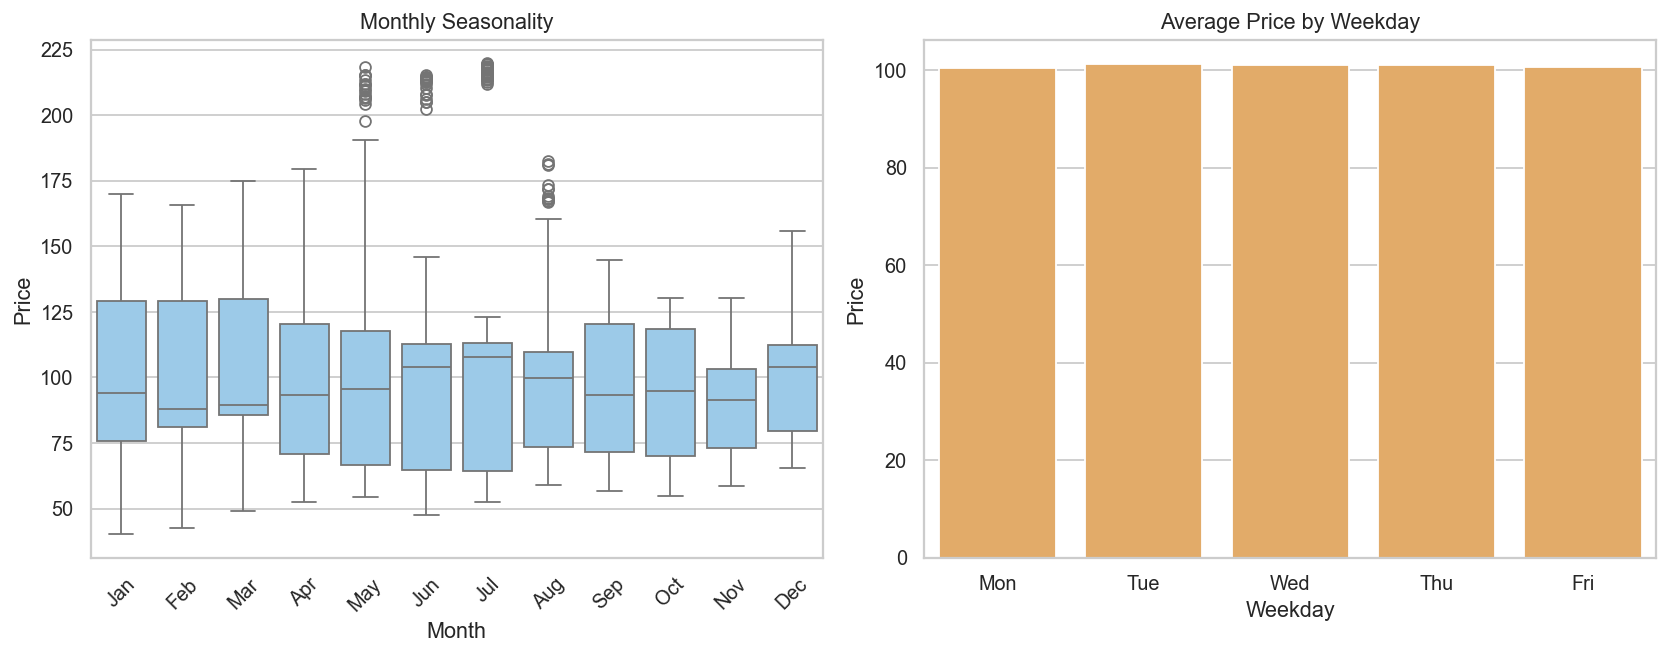

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
sns.boxplot(data=clean_df, x="Month", y="Price", ax=axes[0], color="#90cdf4")
axes[0].set_title("Monthly Seasonality")
axes[0].tick_params(axis="x", rotation=45)

weekday_avg = clean_df.groupby("Weekday", observed=False)["Price"].mean().reset_index()
sns.barplot(data=weekday_avg, x="Weekday", y="Price", ax=axes[1], color="#f6ad55")
axes[1].set_title("Average Price by Weekday")
fig.tight_layout()
fig.savefig(ASSET_DIR / "03_seasonality.png", bbox_inches="tight")
plt.show()


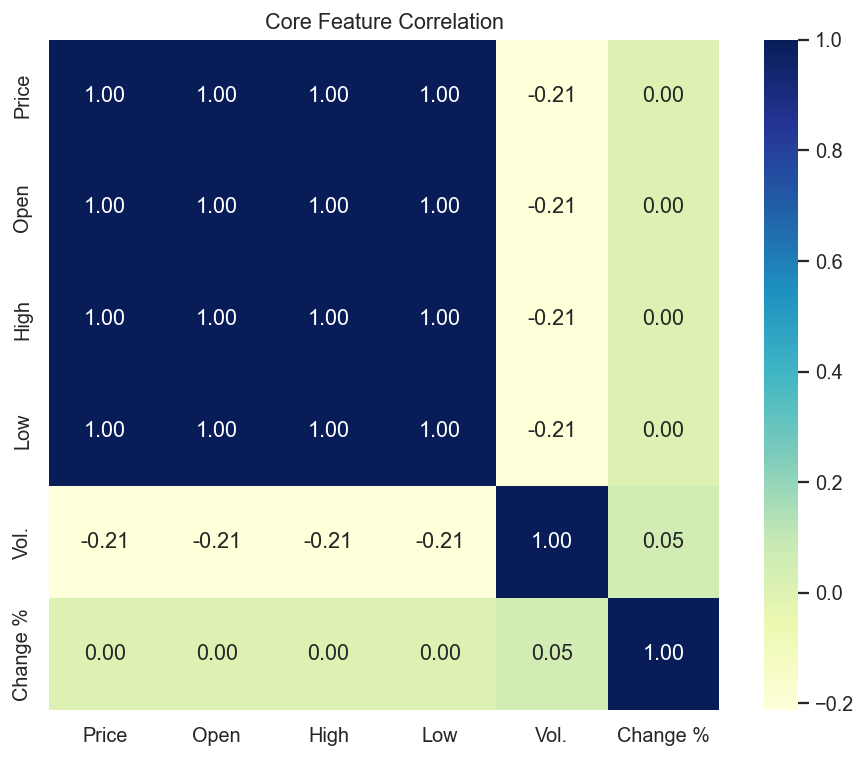

In [8]:
corr_cols = ["Price", "Open", "High", "Low", "Vol.", "Change %"]
corr = clean_df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="YlGnBu", square=True, ax=ax)
ax.set_title("Core Feature Correlation")
fig.tight_layout()
fig.savefig(ASSET_DIR / "04_correlation_heatmap.png", bbox_inches="tight")
plt.show()


In [9]:
turbulence_days = clean_df.nlargest(10, "Volatility_14d")[["Date", "Price", "Change %", "Volatility_14d"]]
turbulence_days


,Date,Price,Change %,Volatility_14d
2214,2024-10-18,105.37,0.01,0.046743
2213,2024-10-17,105.36,-0.79,0.046669
2212,2024-10-16,106.20,-0.40,0.046420
2208,2024-10-10,105.81,-0.68,0.046315
2211,2024-10-15,106.63,-0.45,0.046283
2207,2024-10-09,106.53,0.22,0.046172
2209,2024-10-11,106.44,0.60,0.046153
2206,2024-10-08,106.30,-5.42,0.046134
2210,2024-10-14,107.11,0.63,0.046115
1041,2020-02-21,86.42,0.31,0.045270
